This notebook is intended to run at USDF and can be used to plot the thermal gradients across M1M3 along the X, Y, Z, and Radial axes. 

It has the following T&S package dependencies:
- https://github.com/lsst-ts/ts_m1m3_utils
- https://github.com/lsst-ts/ts_xml
- https://github.com/lsst-ts/ts_utils 
- https://github.com/lsst-ts/ts_salobj 

which can be installed in a users local environment by cloing the repositories and sourcing them in the .user_setups file with something like "setup -j ts_m1m3_utils -r /home/e/edennihy/u/repos/ts_m1m3_utils". 

It also has the following external dependencies which should be installed by a package manager (e.g. pip) into the users environment:
- orjson
- authlib
- pyside6

In [1]:
from lsst.ts.xml.tables.m1m3 import *
from lsst.ts.m1m3.utils import *
from astropy.time import Time, TimeDelta

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib import cm

%matplotlib widget 

# make EFD client
from lsst_efd_client import EfdClient
efd = EfdClient('usdf_efd')

# To plot a specific time window, update and uncomment thisblock.
# time_start = Time('2025-10-27 00:00:00')
# time_end = Time('2025-10-27 10:00:00')

# To plot the last six hours, use this block. 
time_end = Time.now()
time_start = time_end - TimeDelta(6 * 3600, format="sec")

thermocouples = ThermocoupleAnalysis(efd)
await thermocouples.load(time_start, time_end, time_bin=30)

In [2]:
thermocouples.xyz_r_gradients

,intercept,intercept_err,x_gradient,x_gradient_err,y_gradient,y_gradient_err,z_gradient,z_gradient_err,radial_gradient,radial_gradient_err
2025-11-06 00:00:00+00:00,7.610917,0.923986,-0.013212,0.308375,-0.007700,0.305852,0.030587,1.485309,0.032062,0.307116
2025-11-06 00:00:30+00:00,7.608708,0.923758,-0.013350,0.308299,-0.007253,0.305777,0.031631,1.484943,0.032129,0.307051
2025-11-06 00:01:00+00:00,7.609263,0.923876,-0.013090,0.308338,-0.007994,0.305816,0.031726,1.485133,0.031834,0.307073
2025-11-06 00:01:30+00:00,7.609260,0.923805,-0.012944,0.308315,-0.006992,0.305792,0.031719,1.485020,0.032105,0.307073
2025-11-06 00:02:00+00:00,7.609977,0.923955,-0.012614,0.308364,-0.007696,0.305842,0.032133,1.485260,0.031780,0.307106
...,...,...,...,...,...,...,...,...,...,...
2025-11-06 06:13:00+00:00,7.421239,0.895919,-0.002538,0.299008,-0.053673,0.296562,-0.183031,1.440193,-0.041583,0.296650
2025-11-06 06:13:30+00:00,7.418891,0.895663,-0.001961,0.298922,-0.053543,0.296477,-0.182738,1.439780,-0.041802,0.296567
2025-11-06 06:14:00+00:00,7.416938,0.895449,-0.002733,0.298851,-0.053731,0.296406,-0.182946,1.439437,-0.042002,0.296491
2025-11-06 06:14:30+00:00,7.415756,0.895383,-0.002958,0.298829,-0.053847,0.296384,-0.181754,1.439331,-0.042133,0.296466


/tmp/ipykernel_11334/1952648373.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  blues   = cm.get_cmap('Blues')
/tmp/ipykernel_11334/1952648373.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  oranges = cm.get_cmap('Oranges')


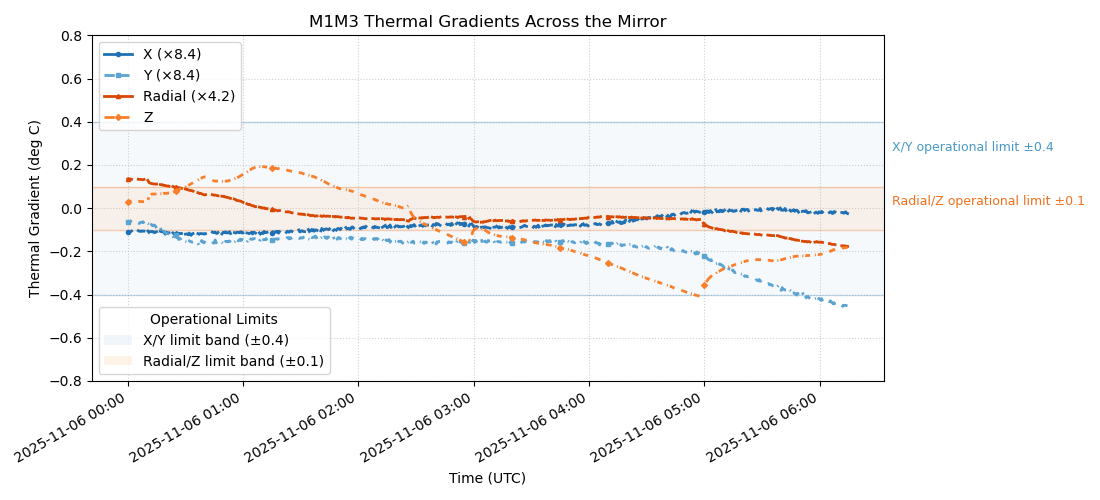

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))

# --- Palettes: same hue family within groups, distinct shades per line ---
blues   = plt.get_cmap('Blues')
oranges = plt.get_cmap('Oranges')

# Line colors (distinct, but clearly grouped)
c_x = blues(0.75)     # darker blue
c_y = blues(0.55)     # lighter blue
c_r = oranges(0.75)   # darker orange
c_z = oranges(0.55)   # lighter orange

# Band colors (very light tint of the group hue)
band_xy = blues(0.25)
band_rz = oranges(0.25)

# --- Shaded operational bands (put behind data) ---
ax.axhspan(-0.4, 0.4, facecolor=band_xy, alpha=0.15, zorder=0)
ax.axhspan(-0.1, 0.1, facecolor=band_rz, alpha=0.20, zorder=0)
ax.axhline(0.4,  color=blues(0.65), linestyle="-", linewidth=1, alpha=0.3)
ax.axhline(-0.4, color=blues(0.65), linestyle="-", linewidth=1, alpha=0.3)
ax.axhline(0.1,  color=oranges(0.65), linestyle="-", linewidth=1, alpha=0.3)
ax.axhline(-0.1, color=oranges(0.65), linestyle="-", linewidth=1, alpha=0.3)

# --- Data lines: distinct per series with styles/markers ---
ln_x, = ax.plot(
    thermocouples.xyz_r_gradients.x_gradient * 8.4,
    label="X (×8.4)", color=c_x, linewidth=2.0, linestyle="-",
    marker="o", markersize=3, markevery=50, zorder=3
)
ln_y, = ax.plot(
    thermocouples.xyz_r_gradients.y_gradient * 8.4,
    label="Y (×8.4)", color=c_y, linewidth=2.0, linestyle="--",
    marker="s", markersize=3, markevery=50, zorder=3
)
ln_r, = ax.plot(
    thermocouples.xyz_r_gradients.radial_gradient * 3.7,
    label="Radial (×4.2)", color=c_r, linewidth=2.0, linestyle="-",
    marker="^", markersize=3, markevery=50, zorder=4
)
ln_z, = ax.plot(
    thermocouples.xyz_r_gradients.z_gradient,
    label="Z", color=c_z, linewidth=2.0, linestyle="--",
    marker="D", markersize=3, markevery=50, zorder=4
)

# --- Time formatting (if index is datetime) ---
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

# --- Colored labels on the right, matching each band hue ---
ax.annotate("X/Y operational limit ±0.4",
            xy=(1, 0.25), xycoords=("axes fraction", "data"),
            xytext=(6, 0), textcoords="offset points",
            ha="left", va="bottom", color=blues(0.6), fontsize=9)
ax.annotate("Radial/Z operational limit ±0.1",
            xy=(1, 0.0), xycoords=("axes fraction", "data"),
            xytext=(6, 0), textcoords="offset points",
            ha="left", va="bottom", color=oranges(0.6), fontsize=9)

# --- Legends: one for data lines, one for bands (with matching colors) ---
data_leg = ax.legend(handles=[ln_x, ln_y, ln_r, ln_z],
                     loc="upper left", frameon=True)
ax.add_artist(data_leg)

band_handles = [
    Patch(facecolor=band_xy, alpha=0.25, label="X/Y limit band (±0.4)"),
    Patch(facecolor=band_rz, alpha=0.25, label="Radial/Z limit band (±0.1)"),
]
ax.legend(handles=band_handles, title="Operational Limits",
          loc="lower left", frameon=True)

# --- Labels, grid, cosmetics ---

# --- Gather all y-data across plotted series ---
ydata = np.concatenate([
    ln_x.get_ydata(),
    ln_y.get_ydata(),
    ln_r.get_ydata(),
    ln_z.get_ydata(),
])

# --- Compute the extrema safely ---
ymin = np.nanmin(ydata)
ymax = np.nanmax(ydata)

# --- Apply conditional limits ---
lower = ymin if ymin < -0.8 else -0.8
upper = ymax if ymax >  0.8 else  0.8
ax.set_ylim(lower, upper)
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Thermal Gradient (deg C)")
ax.set_title("M1M3 Thermal Gradients Across the Mirror")
ax.grid(True, linestyle=":", alpha=0.6)
# Show minutes in the x-axis labels (and full date so it’s unambiguous)
locator = mdates.AutoDateLocator(minticks=6, maxticks=12)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

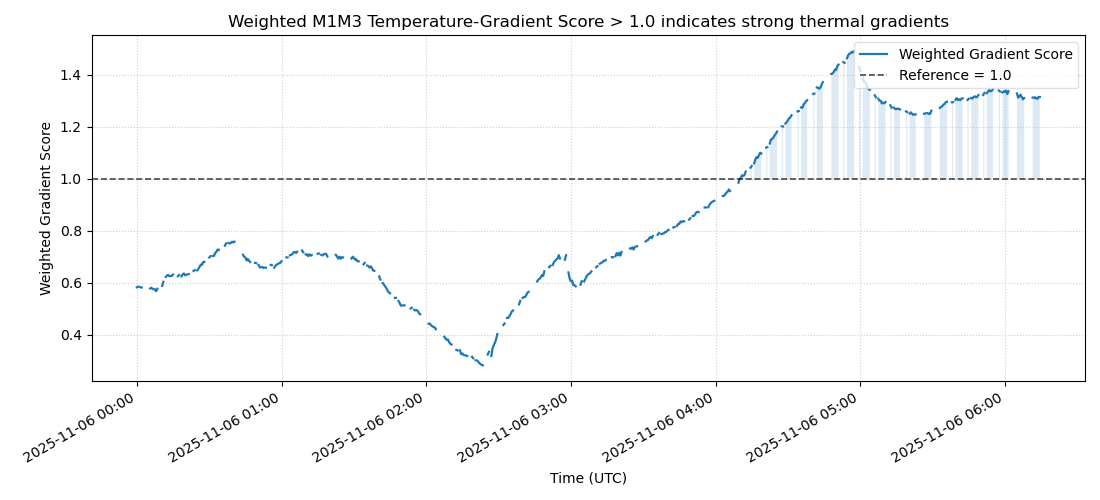

In [4]:
# --- Compute the weighted metric (normalized by each group's operational limit) ---

weighted_gradients = (
      0.3 * np.abs(thermocouples.xyz_r_gradients["z_gradient"]      / 0.1)
    + 0.3 * np.abs(thermocouples.xyz_r_gradients["radial_gradient"]*3.7 / 0.1)
    + 0.2 * np.abs(thermocouples.xyz_r_gradients["y_gradient"]*8.4      / 0.4)
    + 0.2 * np.abs(thermocouples.xyz_r_gradients["x_gradient"]*8.4      / 0.4)
)

thermocouples.xyz_r_gradients = thermocouples.xyz_r_gradients.assign(weighted=weighted_gradients)

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(thermocouples.xyz_r_gradients["weighted"].index, thermocouples.xyz_r_gradients["weighted"].values, label="Weighted Gradient Score", lw=1.6)

# Reference line at 1.0 (≈ operational limit boundary after normalization & weights)
ax.axhline(1.0, ls="--", lw=1.2, color="k", alpha=0.7, label="Reference = 1.0")

# Lightly shade regions where the weighted index exceeds 1.0
ax.fill_between(
    thermocouples.xyz_r_gradients["weighted"].index,
    thermocouples.xyz_r_gradients["weighted"].values,
    1.0,
    where=(thermocouples.xyz_r_gradients["weighted"].values >= 1.0),
    alpha=0.15,
    step=None
)

# Formatting
ax.set_ylabel("Weighted Gradient Score")
ax.set_xlabel("Time (UTC)")

# Show minutes in the x-axis labels (and full date so it’s unambiguous)
locator = mdates.AutoDateLocator(minticks=6, maxticks=12)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="0.85")

ax.set_title("Weighted M1M3 Temperature-Gradient Score > 1.0 indicates strong thermal gradients")
plt.tight_layout()
plt.show()